# 🔗 SVM: Sistema de detección de spam en URLs

## Paso 1: Carga del conjunto de datos

In [10]:
import pandas as pd

total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/NLP-project-tutorial/main/url_spam.csv")
total_data.head()


,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


## Paso 2: Preprocesamiento de los enlaces

### Transformación de categórico a numérico

La columna is_spam viene como True/False. La convertimos a 1/0
para que el modelo pueda trabajar con ella.


In [11]:
total_data["is_spam"] = total_data["is_spam"].apply(lambda x: 1 if x else 0).astype(int)

print("Distribución:")
print(f"  Spam    (1): {len(total_data[total_data.is_spam == 1])}")
print(f"  No spam (0): {len(total_data[total_data.is_spam == 0])}")

total_data.head()


Distribución:
  Spam    (1): 696
  No spam (0): 2303


,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,1
1,https://www.hvper.com/,1
2,https://briefingday.com/m/v4n3i4f3,1
3,https://briefingday.com/n/20200618/m#commentform,0
4,https://briefingday.com/fan,1


### Eliminación de valores duplicados

In [12]:
print(f"Filas antes: {total_data.shape[0]}")
total_data = total_data.drop_duplicates()
total_data = total_data.reset_index(inplace=False, drop=True)
print(f"Filas después: {total_data.shape[0]}")


Filas antes: 2999
Filas después: 2369


In [13]:
print(f"Spam:    {len(total_data.loc[total_data.is_spam == 1])}")
print(f"No spam: {len(total_data.loc[total_data.is_spam == 0])}")


Spam:    244
No spam: 2125


### Procesamiento del texto

Limpiamos cada URL eliminando caracteres especiales, números y espacios
extra para quedarnos solo con las palabras importantes.


In [14]:
import re

def preprocess_text(text):
    # Eliminamos cualquier carácter que no sea letra o espacio
    text = re.sub(r'[^a-z ]', " ", text)
    
    # Eliminamos letras sueltas
    text = re.sub(r'\s+[a-zA-Z]\s+', " ", text)
    text = re.sub(r'\^[a-zA-Z]\s+', " ", text)
    
    # Múltiples espacios en uno
    text = re.sub(r'\s+', " ", text.lower())
    
    # Eliminamos etiquetas HTML
    text = re.sub("&lt;/?.*?&gt;", " &lt;&gt; ", text)
    
    return text.split()

total_data["url"] = total_data["url"].apply(preprocess_text)
total_data.head()


,url,is_spam
0,"[https, briefingday, us, list, manage, com, un...",1
1,"[https, www, hvper, com]",1
2,"[https, briefingday, com, v, i]",1
3,"[https, briefingday, com, m, commentform]",0
4,"[https, briefingday, com, fan]",1


### Lematización y eliminación de stopwords

Lematizar = reducir cada palabra a su forma base (buying → buy).  Stopwords = palabras comunes sin significado (the, a, is...) que eliminamos.


In [15]:
from nltk import download
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

download("wordnet", quiet=True)
download("stopwords", quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = stopwords.words("english")

def lemmatize_text(words):
    tokens = [lemmatizer.lemmatize(word) for word in words]
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [word for word in tokens if len(word) > 3]
    return tokens

total_data["url"] = total_data["url"].apply(lemmatize_text)
total_data.head()


,url,is_spam
0,"[http, briefingday, list, manage, unsubscribe]",1
1,"[http, hvper]",1
2,"[http, briefingday]",1
3,"[http, briefingday, commentform]",0
4,"[http, briefingday]",1


### Nube de palabras — palabras más frecuentes en las URLs

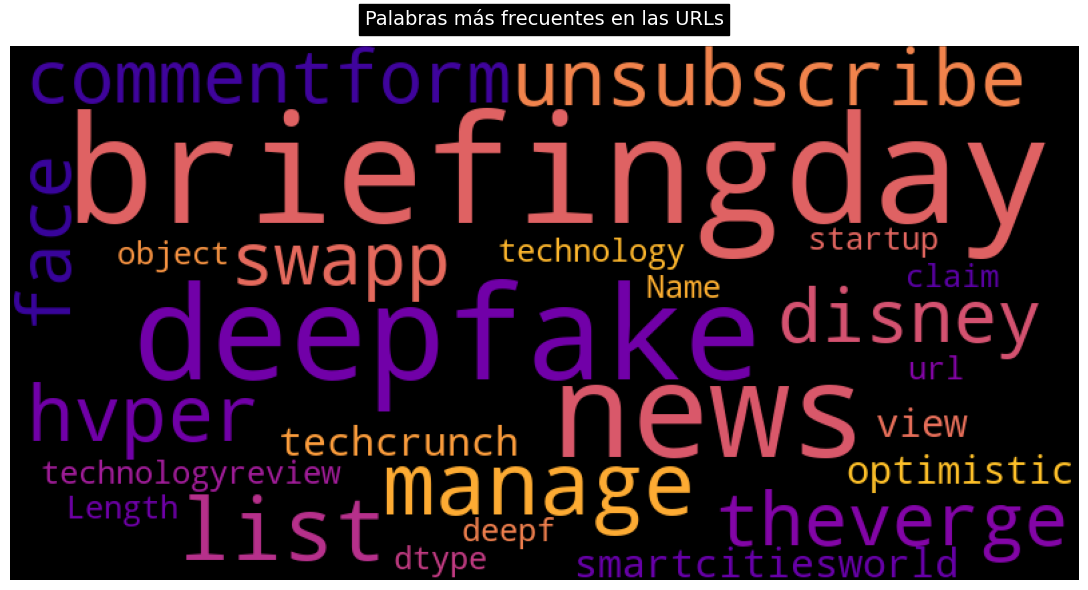

In [16]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800, height=400,
    background_color="black",
    colormap="plasma",         # colores morados y naranja
    max_words=1000,
    min_font_size=20,
    random_state=42
).generate(str(total_data["url"]))

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Palabras más frecuentes en las URLs", fontsize=14, color="white",
          pad=15, backgroundcolor="black")
plt.tight_layout()
plt.show()


### Vectorización TF-IDF

Convertimos las palabras en números. Cada URL se representa como
un vector de 5000 números — uno por cada palabra del vocabulario.


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tokens_list = [" ".join(tokens) for tokens in total_data["url"]]

vectorizer = TfidfVectorizer(max_features=5000, max_df=0.8, min_df=5)
X = vectorizer.fit_transform(tokens_list).toarray()
y = total_data["is_spam"]

print(f"Forma de X: {X.shape}")
print(f"Cada URL = vector de {X.shape[1]} números")


Forma de X: (2369, 538)
Cada URL = vector de 538 números


### División train/test

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")


X_train: (1895, 538)  |  X_test: (474, 538)


## Paso 3: Construcción del SVM

El VM (Support Vector Machine) busca la línea que mejor separa
las URLs de spam de las que no lo son.


In [19]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

model = SVC(kernel="linear", random_state=42)
model.fit(X_train, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [20]:
y_pred = model.predict(X_test)
y_pred


array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

In [21]:
acc_base = accuracy_score(y_test, y_pred)
print(f"Accuracy SVM base: {acc_base:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Spam", "Spam"]))


Accuracy SVM base: 0.9515

              precision    recall  f1-score   support

     No Spam       0.96      0.99      0.97       435
        Spam       0.83      0.51      0.63        39

    accuracy                           0.95       474
   macro avg       0.90      0.75      0.80       474
weighted avg       0.95      0.95      0.95       474



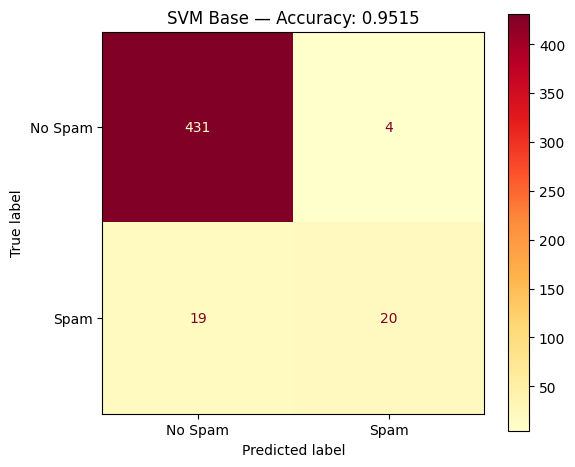

In [22]:
# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Spam", "Spam"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="YlOrRd")
ax.set_title(f"SVM Base — Accuracy: {acc_base:.4f}")
plt.tight_layout()
plt.show()


## Paso 4: Optimización del modelo con Grid Search

In [23]:
import numpy as np
from sklearn.model_selection import GridSearchCV

hyperparams = {
    "C":      [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "kernel": ["linear", "poly", "rbf", "sigmoid"],
    "degree": [1, 2, 3, 4, 5],
    "gamma":  ["scale", "auto"]
}

grid = GridSearchCV(model, hyperparams, scoring="accuracy", cv=5)
grid


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(kernel='l...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'degree': [1, 2, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [24]:
grid.fit(X_train, y_train)
print(f"Mejores hiperparámetros: {grid.best_params_}")


Mejores hiperparámetros: {'C': 1000, 'degree': 1, 'gamma': 'auto', 'kernel': 'poly'}


In [25]:
# Modelo optimizado con los mejores parámetros
opt_model = SVC(
    C=grid.best_params_["C"],
    degree=grid.best_params_["degree"],
    gamma=grid.best_params_["gamma"],
    kernel=grid.best_params_["kernel"],
    random_state=42
)
opt_model.fit(X_train, y_train)
y_pred_opt = opt_model.predict(X_test)

acc_opt = accuracy_score(y_test, y_pred_opt)
print(f"Accuracy SVM optimizado: {acc_opt:.4f}")
print(f"Accuracy SVM base:       {acc_base:.4f}")
print()
print(classification_report(y_test, y_pred_opt, target_names=["No Spam", "Spam"]))


Accuracy SVM optimizado: 0.9620
Accuracy SVM base:       0.9515

              precision    recall  f1-score   support

     No Spam       0.97      0.99      0.98       435
        Spam       0.84      0.67      0.74        39

    accuracy                           0.96       474
   macro avg       0.90      0.83      0.86       474
weighted avg       0.96      0.96      0.96       474



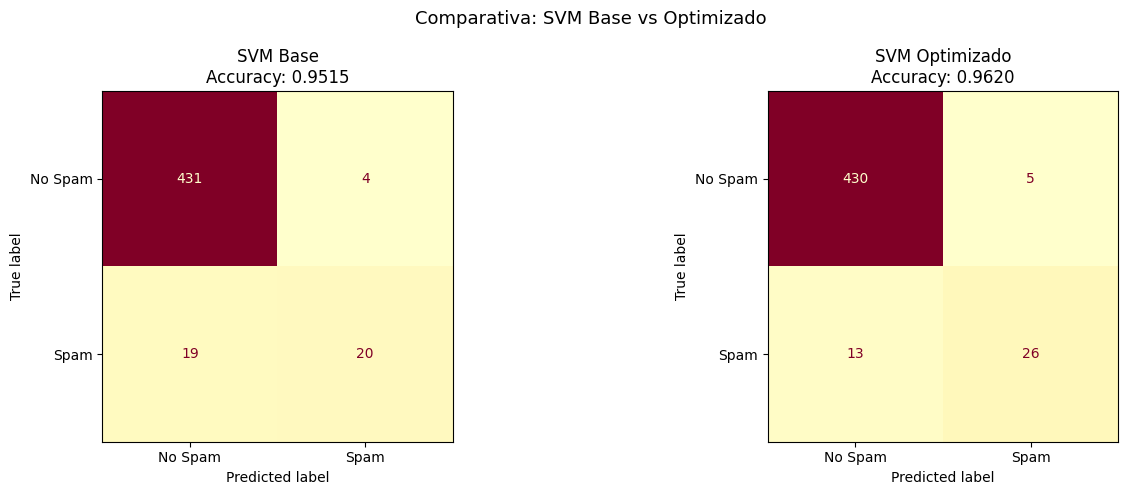

In [26]:
# Comparativa visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_p, titulo, acc in zip(
    axes,
    [y_pred, y_pred_opt],
    ["SVM Base", "SVM Optimizado"],
    [acc_base, acc_opt]
):
    cm = confusion_matrix(y_test, y_p)
    ConfusionMatrixDisplay(cm, display_labels=["No Spam", "Spam"]).plot(
        ax=ax, cmap="YlOrRd", colorbar=False)
    ax.set_title(f"{titulo}\nAccuracy: {acc:.4f}")

plt.suptitle("Comparativa: SVM Base vs Optimizado", fontsize=13)
plt.tight_layout()
plt.show()


## Paso 5: Guardado del modelo

In [27]:
from pickle import dump
import os

os.makedirs("../models", exist_ok=True)

params = grid.best_params_
nombre = f"../models/svm_classifier_C-{params['C']}_deg-{params['degree']}_gam-{params['gamma']}_ker-{params['kernel']}_42.sav"

dump(opt_model, open(nombre, "wb"))
print(f"✅ Modelo guardado en: {nombre}")

# Guardamos también el vectorizador
dump(vectorizer, open("../models/tfidf_vectorizer.sav", "wb"))
print("✅ Vectorizador guardado en: ../models/tfidf_vectorizer.sav")


✅ Modelo guardado en: ../models/svm_classifier_C-1000_deg-1_gam-auto_ker-poly_42.sav
✅ Vectorizador guardado en: ../models/tfidf_vectorizer.sav
